# Службен весник — translation dataset analysis

The corpus run finished on 2026-09-04: **4,937 issues, 446,227 pages, 8,881,038 components,
551,437 mk/sq pairs**, of which 173,133 (31.4%) carry `is_high_quality=True`.
Those pairs are the deliverable — a Macedonian/Albanian parallel corpus for MT training.

`run_report.txt` answers *"did the run complete"*. This notebook answers *"is the corpus any
good"*, and writes back a cleaned, annotated copy.

## What it does

| § | |
|---|---|
| 1 | Consolidate 4,937 per-issue Parquet objects into one file (idempotent) |
| 2 | Integrity audit — reconcile against `run_report.txt`, check keys and nulls |
| 3 | Corpus profile — coverage by year, component types, confidence distributions |
| 4 | Pair-quality forensics — length, script, numerals, language ID, OCR |
| 5 | **`quality_confidence`** — a continuous score, added *alongside* `is_high_quality` |
| 6 | Duplicate flagging — flag, never drop |
| 7 | Issue-disjoint train/dev/test split |
| 8 | Write the cleaned corpus back to the bucket |
| 9 | Summary |

## Five things about this data that are easy to get wrong

1. **There is no `year` column.** Year lives only in the `year=<y>/` path segment and inside
   `slv_identifier`. §1 materialises it; §2 cross-checks the two sources agree.

2. **The pair objects are schema-heterogeneous, and the split is dated.**
   `mk_component_id`, `sq_component_id`, `mk_component_type` and `sq_component_type` were
   added to `PAIR_SCHEMA` in commit `a53eb3c` on 2026-09-01 — *while the run was in flight*
   (2026-08-31 → 09-04). The resume scan keys on the object existing, not on its schema
   (`RUNBOOK.md`), so issues written before that deploy keep the 8-column shape forever.
   And because `run_corpus.sh` runs **2019+ first**, the missing ids are expected to sit in
   the *recent, highest-yield* years rather than in old ones. §2 measures this per year
   instead of assuming it.

3. **`match_confidence` is two incomparable quantities in one column.** `batch.py` runs
   `matcher=HYBRID` with `gale_church_fallback=True`, so the column mixes Hybrid scores
   (five structural terms plus a length-gated SONAR cosine) with Gale-Church normal-tails
   computed from **length deviation alone**. `PAIR_SCHEMA` has no `match_method` column.
   §5 recovers the method where it can — see the note in §2.

4. **`slv_identifier` is not a stable key.** It is a creation-time rank within a month
   folder, and re-uploading an old PDF renumbers its neighbours. The stable keys are
   `filename` (the source PDF object) and the two `*_component_id`s. The train/dev/test
   split in §7 is therefore hashed from `filename`.

5. **`is_high_quality` is a boolean over four independent failure modes**, and is fully
   rederivable from the columns beside it — that is deliberate (`dataset.py`). This notebook
   never overwrites it. `quality_confidence` is a *new* column.

---
## 0. Setup

Runs on Colab against the bucket, or locally against a directory of pair Parquet files
(set `LOCAL_SMOKE_TEST = True` in the config cell — useful for exercising the whole
notebook on `out_batch/` without touching GCS).

In [ ]:
import importlib
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules


def _ensure(pip_name: str, module: str | None = None) -> None:
    try:
        importlib.import_module(module or pip_name)
    except ImportError:
        print(f"installing {pip_name} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name], check=True)


if IN_COLAB:
    _ensure("gcsfs")
_ensure("lingua-language-detector", "lingua")

print("running in colab:", IN_COLAB)

installing lingua-language-detector ...
running in colab: True


In [ ]:
import hashlib
import json
import math
import re
import time
import warnings
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

print("pandas", pd.__version__, "| pyarrow", pa.__version__)

pandas 2.2.3 | pyarrow 18.1.0


### Configuration

Every threshold below mirrors a field in `slusben_vesnik/config.py`. They are named
constants rather than literals so a sweep only has to touch this cell.

In [ ]:
# ---- where the data lives ---------------------------------------------------
BUCKET = "sl_vesnik_izdanija"
PAIRS_PREFIX = "DATA_PARQUET"        # written by batch.py; NEVER written to from here
CLEAN_PREFIX = "DATA_CLEAN"          # this notebook's own output prefix

CONSOLIDATED_URI = f"{BUCKET}/{CLEAN_PREFIX}/pairs_consolidated.parquet"
CLEAN_URI = f"{BUCKET}/{CLEAN_PREFIX}/pairs_clean.parquet"

# ---- local smoke test -------------------------------------------------------
# True  -> read LOCAL_GLOB instead of the bucket, write nothing to GCS.
#          out_batch/sl-2024-09.pairs.parquet is the *old 8-column* shape, which makes it
#          the free test case for the schema backfill in load_pairs().
LOCAL_SMOKE_TEST = False
LOCAL_GLOB = "../out_batch/*.pairs.parquet"
LOCAL_OUT_DIR = Path("_local")

# ---- thresholds, mirroring slusben_vesnik/config.py -------------------------
PAIR_HQ_MIN_CONFIDENCE = 0.85        # Settings.pair_high_quality_min_confidence
PAIR_HQ_MIN_OCR_CONFIDENCE = 0.70    # Settings.pair_high_quality_min_ocr_confidence
SEMANTIC_MIN_MATCH_SCORE = 0.76      # Settings.semantic_min_match_score (the matcher floor)

# ---- quality_confidence knobs (see section 5) -------------------------------
MATCH_RAMP = (SEMANTIC_MIN_MATCH_SCORE, 0.95)
OCR_RAMP = (0.50, 0.85)
GALE_CHURCH_PENALTY = 0.35           # method_term for an inferred Gale-Church link

TEXT_WEIGHTS = {
    "numeric_overlap": 0.35,
    "lingua_agreement": 0.30,
    "script_purity": 0.20,
    "length_ratio": 0.15,
}
assert abs(sum(TEXT_WEIGHTS.values()) - 1.0) < 1e-9

# ---- split -------------------------------------------------------------------
SPLIT_BOUNDS = {"train": (0, 90), "dev": (90, 95), "test": (95, 100)}

# ---- what run_report.txt says, for the §2 reconciliation --------------------
EXPECTED_PAIRS = 551_437
EXPECTED_HQ = 173_133
EXPECTED_ISSUES_OK = 4_937
EXPECTED_ISSUES_WITH_PAIRS = 2_674

# year -> (pairs, high quality), transcribed from run_report.txt §7
EXPECTED_BY_YEAR = {
    2001: (1159, 66),      2002: (5875, 589),     2003: (7622, 1388),
    2004: (11611, 1819),   2005: (10292, 1354),   2006: (12966, 2092),
    2007: (16714, 3004),   2008: (18348, 4570),   2009: (12313, 3060),
    2010: (18747, 4226),   2011: (24667, 7923),   2012: (15934, 3794),
    2013: (20005, 5793),   2014: (18568, 5748),   2015: (26367, 10138),
    2016: (17163, 6465),   2017: (2547, 694),     2018: (11677, 4092),
    2019: (10382, 3231),   2020: (16780, 6572),   2021: (39962, 15563),
    2022: (45384, 16756),  2023: (64940, 21336),  2024: (63913, 23469),
    2025: (57501, 19391),
}
assert sum(p for p, _ in EXPECTED_BY_YEAR.values()) == EXPECTED_PAIRS
assert sum(h for _, h in EXPECTED_BY_YEAR.values()) == EXPECTED_HQ

print(f"target: {EXPECTED_PAIRS:,} pairs / {EXPECTED_HQ:,} high quality")
print("mode:", "LOCAL SMOKE TEST" if LOCAL_SMOKE_TEST else f"bucket gs://{BUCKET}")

target: 551,437 pairs / 173,133 high quality
mode: bucket gs://sl_vesnik_izdanija


`PAIR_SCHEMA` is **copied** from `slusben_vesnik/dataset.py` rather than imported: the repo
is private, and installing it into Colab would drag in `doclayout-yolo` and torch for no
benefit here. It has to stay in step with `dataset.py` — if a column is ever added there,
add it here too.

In [ ]:
# --- keep in step with slusben_vesnik/dataset.py :: PAIR_SCHEMA --------------
PAIR_SCHEMA = pa.schema(
    [
        ("slv_identifier", pa.string()),
        ("filename", pa.string()),
        ("mk_component_id", pa.string()),
        ("sq_component_id", pa.string()),
        ("mk_text", pa.string()),
        ("sq_text", pa.string()),
        ("mk_component_type", pa.string()),
        ("sq_component_type", pa.string()),
        ("mk_ocr_confidence", pa.float64()),
        ("sq_ocr_confidence", pa.float64()),
        ("match_confidence", pa.float64()),
        ("is_high_quality", pa.bool_()),
    ]
)

# The four columns added in commit a53eb3c (2026-09-01), mid-run. Their presence in a file
# is what distinguishes the 12-column shape from the 8-column one.
POST_A53EB3C_COLUMNS = [
    "mk_component_id",
    "sq_component_id",
    "mk_component_type",
    "sq_component_type",
]
print(len(PAIR_SCHEMA), "columns")

12 columns


### Authentication and filesystem

In [ ]:
FS = None
if not LOCAL_SMOKE_TEST:
    if IN_COLAB:
        from google.colab import auth

        auth.authenticate_user()
    import gcsfs

    FS = gcsfs.GCSFileSystem()
    print("bucket reachable:", FS.exists(BUCKET))
else:
    LOCAL_OUT_DIR.mkdir(exist_ok=True)
    print("local mode; writing artefacts to", LOCAL_OUT_DIR.resolve())

bucket reachable: True


### Chart styling

One palette for the whole notebook, applied in fixed slot order so a colour always means
the same thing. Slots 1–4 (blue / orange / aqua / yellow) come from a validated
colourblind-safe categorical set; magnitude bars use a single-hue blue ramp rather than a
categorical cycle.

In [ ]:
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]   # categorical, fixed order
SEQ_BLUE = "#2a78d6"                                     # magnitude / single-series
INK = "#0b0b0b"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"
STATUS = {"good": "#0ca30c", "warning": "#fab219", "critical": "#d03b3b"}

plt.rcParams.update(
    {
        "figure.figsize": (11, 4.2),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": "#c3c2b7",
        "axes.labelcolor": INK,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "text.color": INK,
        "legend.frameon": False,
        "lines.linewidth": 2.0,
        "font.size": 10,
    }
)


def thousands(ax, axis="y"):
    '''Format an axis with thousands separators.'''
    fmt = plt.FuncFormatter(lambda v, _: f"{v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)
    return ax

---
## 1. Ingest and consolidate

4,937 objects is 4,937 GCS round-trips. This section reads them once, in parallel, and
writes a single `pairs_consolidated.parquet`; every later run reads that file in seconds.
Re-run with `load_pairs(force_rebuild=True)` if the bucket has changed.

Three columns are materialised here that do not exist on disk:

* **`source_object`** — which Parquet object the row came from.
* **`year_from_path`** — parsed out of the `year=<y>/` hive segment (`-1` when the path has
  no such segment, which is the case for local files).
* **`schema_shape`** — `12col` or `8col`, i.e. whether this object was written before or
  after the `a53eb3c` deploy. This is what §2 uses to size the missing-`component_id`
  region.

The read goes column-by-column against `PAIR_SCHEMA` so an 8-column object gets explicit
nulls for the four missing fields, rather than failing the concat or silently producing
two different shapes.

In [ ]:
import glob as _glob

_YEAR_IN_PATH = re.compile(r"year=(\d{4})")


def read_pair_file(path, filesystem=None) -> pa.Table:
    '''One pair object, conformed to PAIR_SCHEMA with provenance columns attached.

    Missing columns are filled with typed nulls rather than dropped, so the 8-column
    objects written before commit a53eb3c concat cleanly with the 12-column ones.
    '''
    table = pq.read_table(path, filesystem=filesystem)
    present = set(table.column_names)

    columns = []
    for field in PAIR_SCHEMA:
        if field.name in present:
            columns.append(table.column(field.name).cast(field.type))
        else:
            columns.append(pa.chunked_array([pa.nulls(table.num_rows, type=field.type)]))

    out = pa.Table.from_arrays(columns, schema=PAIR_SCHEMA)
    n = out.num_rows

    shape = "12col" if set(POST_A53EB3C_COLUMNS) <= present else "8col"
    found = _YEAR_IN_PATH.search(str(path))
    year = int(found.group(1)) if found else -1   # -1 == no hive segment in this path

    out = out.append_column("source_object", pa.array([str(path)] * n, pa.string()))
    out = out.append_column("schema_shape", pa.array([shape] * n, pa.string()))
    out = out.append_column("year_from_path", pa.array([year] * n, pa.int16()))
    return out


def list_pair_objects() -> list:
    if LOCAL_SMOKE_TEST:
        return sorted(_glob.glob(LOCAL_GLOB))
    return sorted(FS.glob(f"{BUCKET}/{PAIRS_PREFIX}/year=*/*.parquet"))


def build_consolidated(max_workers: int = 32) -> pa.Table:
    paths = list_pair_objects()
    if not paths:
        raise RuntimeError("no pair objects found -- check BUCKET/LOCAL_GLOB")
    print(f"reading {len(paths):,} pair objects with {max_workers} threads ...")

    tables, done, t0 = [], 0, time.time()
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        for table in pool.map(lambda p: read_pair_file(p, filesystem=FS), paths):
            tables.append(table)
            done += 1
            if done % 500 == 0 or done == len(paths):
                rate = done / max(time.time() - t0, 1e-9)
                print(f"  {done:>6,}/{len(paths):,}  ({rate:5.1f} obj/s)")

    combined = pa.concat_tables(tables)
    print(f"{combined.num_rows:,} rows from {len(paths):,} objects "
          f"in {time.time() - t0:,.1f}s")
    return combined


def load_pairs(force_rebuild: bool = False) -> pa.Table:
    '''The consolidated pair table. Builds and caches it on first use.'''
    if not LOCAL_SMOKE_TEST and not force_rebuild and FS.exists(CONSOLIDATED_URI):
        print("reading cached", CONSOLIDATED_URI)
        return pq.read_table(CONSOLIDATED_URI, filesystem=FS)

    table = build_consolidated()
    if not LOCAL_SMOKE_TEST:
        print("caching to", CONSOLIDATED_URI)
        pq.write_table(table, CONSOLIDATED_URI, filesystem=FS, compression="zstd")
    return table

In [ ]:
pairs_table = load_pairs()
df = pairs_table.to_pandas()

# year: prefer the hive segment, fall back to the identifier's leading field.
df["year_from_identifier"] = (
    pd.to_numeric(df["slv_identifier"].str.slice(0, 4), errors="coerce")
    .fillna(-1)
    .astype("int16")
)
df["year"] = np.where(
    df["year_from_path"] > 0, df["year_from_path"], df["year_from_identifier"]
).astype("int16")

for column in ("mk_text", "sq_text"):
    df[column] = df[column].fillna("")

print(f"{len(df):,} rows x {df.shape[1]} columns")
print(f"memory: {df.memory_usage(deep=True).sum() / 1e6:,.0f} MB")
df.head(3)

reading 4,937 pair objects with 32 threads ...
     500/4,937  ( 27.3 obj/s)
   1,000/4,937  ( 30.2 obj/s)
   1,500/4,937  ( 31.0 obj/s)
   2,000/4,937  ( 31.7 obj/s)
   2,500/4,937  ( 33.1 obj/s)
   3,000/4,937  ( 35.3 obj/s)
   3,500/4,937  ( 37.1 obj/s)
   4,000/4,937  ( 37.6 obj/s)
   4,500/4,937  ( 38.0 obj/s)
   4,937/4,937  ( 38.3 obj/s)
551,437 rows from 4,937 objects in 129.0s
caching to sl_vesnik_izdanija/DATA_CLEAN/pairs_consolidated.parquet
551,437 rows x 17 columns
memory: 1,021 MB


,slv_identifier,filename,mk_component_id,sq_component_id,mk_text,sq_text,mk_component_type,sq_component_type,mk_ocr_confidence,sq_ocr_confidence,match_confidence,is_high_quality,source_object,schema_shape,year_from_path,year_from_identifier,year
0,2001-10-7,81D291820F6B40629F2092494583AB8E__СЛУЖБЕН_ВЕСН...,81D291820F6B40629F2092494583AB8E__СЛУЖБЕН_ВЕСН...,81D291820F6B40629F2092494583AB8E__СЛУЖБЕН_ВЕСН...,2. СОДРЖИНА НА ПОНУДАТА 2 1 П б,TENDERING FOR ELIGIBLE CONTRACTORS,title,title,NaN,NaN,0.8126,False,sl_vesnik_izdanija/DATA_PARQUET/year=2001/2001...,12col,2001,2001,2001
1,2001-10-7,81D291820F6B40629F2092494583AB8E__СЛУЖБЕН_ВЕСН...,81D291820F6B40629F2092494583AB8E__СЛУЖБЕН_ВЕСН...,81D291820F6B40629F2092494583AB8E__СЛУЖБЕН_ВЕСН...,"Д Д 2.1. Понудата треба да ги содржи името, ад...",PROJECT: Lake Ohrid Environmental Protection -...,plain_text,title,NaN,NaN,0.9048,False,sl_vesnik_izdanija/DATA_PARQUET/year=2001/2001...,12col,2001,2001,2001
2,2001-10-7,81D291820F6B40629F2092494583AB8E__СЛУЖБЕН_ВЕСН...,81D291820F6B40629F2092494583AB8E__СЛУЖБЕН_ВЕСН...,81D291820F6B40629F2092494583AB8E__СЛУЖБЕН_ВЕСН...,р 2.5. Понудата треба да го содржи рокот и нач...,Financed by: KfW Client: M.J.P. Proaqua - Stru...,plain_text,title,NaN,NaN,0.9194,False,sl_vesnik_izdanija/DATA_PARQUET/year=2001/2001...,12col,2001,2001,2001


---
## 2. Integrity audit

Everything here is a comparison against a number that came from somewhere else —
`run_report.txt`, or an invariant the writer is supposed to guarantee. A mismatch is
reported as a finding about the data; nothing is silently reconciled.

In [ ]:
def check(label: str, observed, expected, tolerance: int = 0) -> dict:
    delta = observed - expected
    ok = abs(delta) <= tolerance
    print(f"{'PASS' if ok else 'FAIL'}  {label:<34} observed {observed:>10,}   "
          f"expected {expected:>10,}   delta {delta:+,}")
    return {"check": label, "observed": observed, "expected": expected,
            "delta": delta, "ok": ok}


findings = [
    check("total pairs", len(df), EXPECTED_PAIRS),
    check("high quality", int(df["is_high_quality"].sum()), EXPECTED_HQ),
    check("issues yielding pairs", df["source_object"].nunique(), EXPECTED_ISSUES_WITH_PAIRS),
    check("distinct source PDFs", df["filename"].nunique(), EXPECTED_ISSUES_WITH_PAIRS),
]
print()
print(f"objects with zero pairs (implied): "
      f"{EXPECTED_ISSUES_OK - df['source_object'].nunique():,} "
      f"of {EXPECTED_ISSUES_OK:,} ok issues -- these are the monolingual issues, "
      f"run_report.txt says 2,263")

PASS  total pairs                        observed    551,437   expected    551,437   delta +0
PASS  high quality                       observed    173,133   expected    173,133   delta +0
PASS  issues yielding pairs              observed      2,674   expected      2,674   delta +0
PASS  distinct source PDFs               observed      2,674   expected      2,674   delta +0

objects with zero pairs (implied): 2,263 of 4,937 ok issues -- these are the monolingual issues, run_report.txt says 2,263


In [ ]:
# per-year reconciliation against run_report.txt section 7
observed = (
    df.groupby("year")
      .agg(pairs=("is_high_quality", "size"), hq=("is_high_quality", "sum"))
)
expected = pd.DataFrame(
    [{"year": y, "pairs_expected": p, "hq_expected": h}
     for y, (p, h) in EXPECTED_BY_YEAR.items()]
).set_index("year")

recon = expected.join(observed, how="outer").fillna(0).astype(int)
recon["pairs_delta"] = recon["pairs"] - recon["pairs_expected"]
recon["hq_delta"] = recon["hq"] - recon["hq_expected"]
recon["hq_rate"] = (recon["hq"] / recon["pairs"].replace(0, np.nan)).round(3)

mismatched = recon[(recon["pairs_delta"] != 0) | (recon["hq_delta"] != 0)]
print(f"{len(mismatched)} of {len(recon)} years disagree with run_report.txt")
recon[["pairs_expected", "pairs", "pairs_delta",
       "hq_expected", "hq", "hq_delta", "hq_rate"]]

0 of 25 years disagree with run_report.txt


,pairs_expected,pairs,pairs_delta,hq_expected,hq,hq_delta,hq_rate
year,,,,,,,
2001,1159,1159,0,66,66,0,0.057
2002,5875,5875,0,589,589,0,0.100
2003,7622,7622,0,1388,1388,0,0.182
2004,11611,11611,0,1819,1819,0,0.157
2005,10292,10292,0,1354,1354,0,0.132
2006,12966,12966,0,2092,2092,0,0.161
2007,16714,16714,0,3004,3004,0,0.180
2008,18348,18348,0,4570,4570,0,0.249
2009,12313,12313,0,3060,3060,0,0.249


In [ ]:
# does the hive path agree with the identifier?
both = df[(df["year_from_path"] > 0) & (df["year_from_identifier"] > 0)]
disagree = both[both["year_from_path"] != both["year_from_identifier"]]
print(f"rows where year= segment and slv_identifier disagree: {len(disagree):,} "
      f"({len(disagree) / max(len(both), 1):.4%})")
if len(disagree):
    display(disagree[["slv_identifier", "year_from_path", "year_from_identifier",
                      "source_object"]].head(10))

rows where year= segment and slv_identifier disagree: 0 (0.0000%)


### The schema split

`mk_component_id` and friends landed mid-run. If the split follows the run order rather
than the publication year, the 8-column mass sits in **2019+** — the years `run_corpus.sh`
processed first — not in the old ones.

schema_shape
12col    551437

rows without component ids: 0 (0.0% of the corpus)


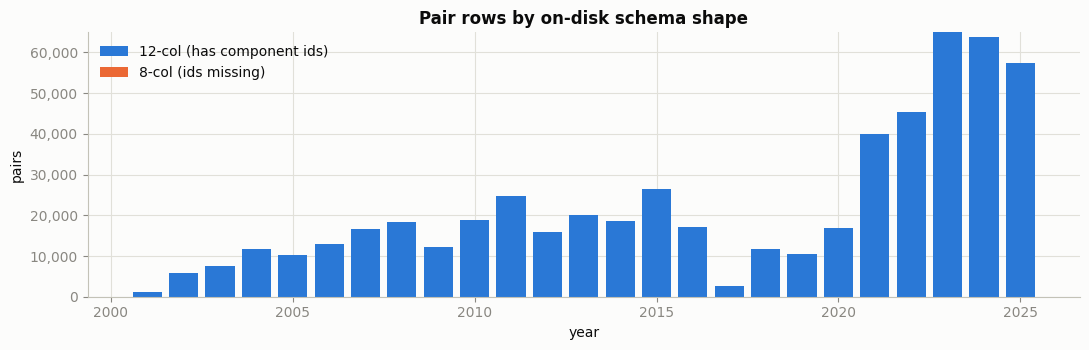

schema_shape,8col,12col,total,pct_8col
year,,,,
2001,0,1159,1159,0.0
2002,0,5875,5875,0.0
2003,0,7622,7622,0.0
2004,0,11611,11611,0.0
2005,0,10292,10292,0.0
2006,0,12966,12966,0.0
2007,0,16714,16714,0.0
2008,0,18348,18348,0.0
2009,0,12313,12313,0.0


In [ ]:
shape_by_year = pd.crosstab(df["year"], df["schema_shape"])
for column in ("8col", "12col"):
    if column not in shape_by_year:
        shape_by_year[column] = 0
shape_by_year["total"] = shape_by_year["8col"] + shape_by_year["12col"]
shape_by_year["pct_8col"] = (shape_by_year["8col"] / shape_by_year["total"]).round(3)

overall = df["schema_shape"].value_counts()
print(overall.to_string())
print(f"\nrows without component ids: {overall.get('8col', 0):,} "
      f"({overall.get('8col', 0) / len(df):.1%} of the corpus)")

fig, ax = plt.subplots(figsize=(11, 3.6))
years = shape_by_year.index.astype(int)
ax.bar(years, shape_by_year["12col"], color=SERIES[0], label="12-col (has component ids)")
ax.bar(years, shape_by_year["8col"], bottom=shape_by_year["12col"],
       color=SERIES[1], label="8-col (ids missing)")
ax.set_title("Pair rows by on-disk schema shape")
ax.set_xlabel("year")
ax.set_ylabel("pairs")
ax.legend(loc="upper left")
thousands(ax)
plt.tight_layout()
plt.show()

shape_by_year[["8col", "12col", "total", "pct_8col"]]

In [ ]:
# null rate per column
nulls = pd.DataFrame({
    "nulls": df[[f.name for f in PAIR_SCHEMA]].isna().sum(),
})
nulls["pct"] = (nulls["nulls"] / len(df)).round(4)
display(nulls)

# key invariants the writer is supposed to guarantee (dataset.py: links are 1:1 sq -> mk)
have_ids = df[df["sq_component_id"].notna()]
dup_sq = int(have_ids["sq_component_id"].duplicated().sum())
reused_mk = int(have_ids["mk_component_id"].duplicated().sum())
print(f"\nrows with component ids : {len(have_ids):,}")
print(f"duplicate sq_component_id: {dup_sq:,}   (invariant: 0 -- one row per sq component)")
print(f"reused  mk_component_id  : {reused_mk:,}   (invariant: 0 under 1:1 linking)")
findings.append(check("duplicate sq_component_id", dup_sq, 0))
findings.append(check("reused mk_component_id", reused_mk, 0))

,nulls,pct
slv_identifier,0,0.0000
filename,0,0.0000
mk_component_id,0,0.0000
sq_component_id,0,0.0000
mk_text,0,0.0000
sq_text,0,0.0000
mk_component_type,0,0.0000
sq_component_type,0,0.0000
mk_ocr_confidence,483110,0.8761
sq_ocr_confidence,470240,0.8528



rows with component ids : 551,437
duplicate sq_component_id: 0   (invariant: 0 -- one row per sq component)
reused  mk_component_id  : 22,826   (invariant: 0 under 1:1 linking)
PASS  duplicate sq_component_id          observed          0   expected          0   delta +0
FAIL  reused mk_component_id             observed     22,826   expected          0   delta +22,826


### Recovering `match_method`

`PAIR_SCHEMA` does not record whether a link came from the Hybrid matcher or from the
Gale-Church fallback, and the two write *incomparable* numbers into `match_confidence` — a
weighted structural+semantic score in one case, a normal-tail on length deviation in the
other.

The flag can be partly inverted, though. `is_high_quality` fails for exactly four reasons,
and three of them are rederivable from columns that are present. So a row that fails the
flag while passing all three rederivable clauses can only have failed on the fourth:

    is_high_quality == False
      AND match_confidence >= 0.85
      AND both texts non-empty
      AND both OCR confidences null or >= 0.70
      =>  the link came from Gale-Church

**The blind spot:** this identifies Gale-Church rows only where they scored **≥ 0.85**.
Gale-Church links below that threshold are indistinguishable from weak Hybrid links using
the pair table alone; separating them would need `COMPONENT_PARQUET`. The size of that
unresolvable region is reported below and repeated in the final summary.

In [ ]:
ocr_min_ok = (
    (df["mk_ocr_confidence"].isna() | (df["mk_ocr_confidence"] >= PAIR_HQ_MIN_OCR_CONFIDENCE))
    & (df["sq_ocr_confidence"].isna() | (df["sq_ocr_confidence"] >= PAIR_HQ_MIN_OCR_CONFIDENCE))
)
both_nonempty = (df["mk_text"].str.strip() != "") & (df["sq_text"].str.strip() != "")
conf_ok = df["match_confidence"].fillna(0.0) >= PAIR_HQ_MIN_CONFIDENCE

df["gale_church_inferred"] = (~df["is_high_quality"]) & conf_ok & both_nonempty & ocr_min_ok

# sanity: the three rederivable clauses must reproduce is_high_quality wherever the
# method clause is not the deciding one.
rederived_hq = conf_ok & both_nonempty & ocr_min_ok
print(f"rows passing the 3 rederivable clauses : {int(rederived_hq.sum()):,}")
print(f"of which flagged high quality          : {int((rederived_hq & df['is_high_quality']).sum()):,}")
print(f"=> inferred Gale-Church                : {int(df['gale_church_inferred'].sum()):,} "
      f"({df['gale_church_inferred'].mean():.1%} of all pairs)")

unresolvable = int(((~df["is_high_quality"]) & ~rederived_hq).sum())
print(f"\nBLIND SPOT: {unresolvable:,} low-quality rows ({unresolvable / len(df):.1%}) fail at "
      f"least one rederivable clause,\n            so a sub-0.85 Gale-Church link there cannot be "
      f"told from a weak Hybrid one.")

# every high-quality row must be Hybrid by construction
assert not (df["is_high_quality"] & df["gale_church_inferred"]).any()

rows passing the 3 rederivable clauses : 236,074
of which flagged high quality          : 173,133
=> inferred Gale-Church                : 62,941 (11.4% of all pairs)

BLIND SPOT: 315,363 low-quality rows (57.2%) fail at least one rederivable clause,
            so a sub-0.85 Gale-Church link there cannot be told from a weak Hybrid one.


---
## 3. Corpus profile and coverage

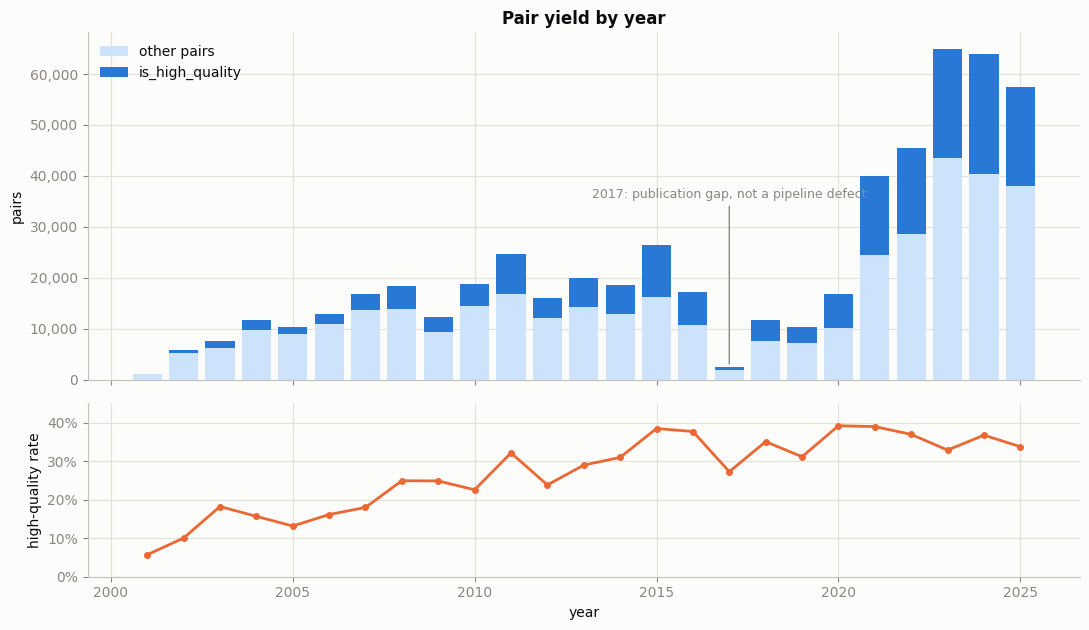

,pairs,hq,issues,hq_rate,pairs_per_issue
year,,,,,
2001,1159,66,30,0.056946,38.6
2002,5875,589,27,0.100255,217.6
2003,7622,1388,47,0.182104,162.2
2004,11611,1819,43,0.156662,270.0
2005,10292,1354,50,0.131558,205.8
2006,12966,2092,60,0.161345,216.1
2007,16714,3004,86,0.179730,194.3
2008,18348,4570,72,0.249073,254.8
2009,12313,3060,70,0.248518,175.9


In [ ]:
by_year = (
    df.groupby("year")
      .agg(pairs=("is_high_quality", "size"),
           hq=("is_high_quality", "sum"),
           issues=("filename", "nunique"))
)
by_year["hq_rate"] = by_year["hq"] / by_year["pairs"]
by_year["pairs_per_issue"] = (by_year["pairs"] / by_year["issues"]).round(1)

fig, (top, bottom) = plt.subplots(
    2, 1, figsize=(11, 6.4), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
years = by_year.index.astype(int)
top.bar(years, by_year["pairs"] - by_year["hq"], color="#cde2fb", label="other pairs")
top.bar(years, by_year["hq"], bottom=by_year["pairs"] - by_year["hq"],
        color=SEQ_BLUE, label="is_high_quality")
top.set_ylabel("pairs")
top.set_title("Pair yield by year")
top.legend(loc="upper left")
thousands(top)

bottom.plot(years, by_year["hq_rate"], color=SERIES[1], marker="o", markersize=4)
bottom.set_ylabel("high-quality rate")
bottom.set_xlabel("year")
bottom.set_ylim(0, max(by_year["hq_rate"].max() * 1.15, 0.1))
bottom.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))

if 2017 in by_year.index:
    top.annotate(
        "2017: publication gap, not a pipeline defect",
        xy=(2017, by_year.loc[2017, "pairs"]),
        xytext=(2017, by_year["pairs"].max() * 0.55),
        ha="center", fontsize=9, color=INK_MUTED,
        arrowprops={"arrowstyle": "-", "color": INK_MUTED, "linewidth": 1},
    )

plt.tight_layout()
plt.show()
by_year

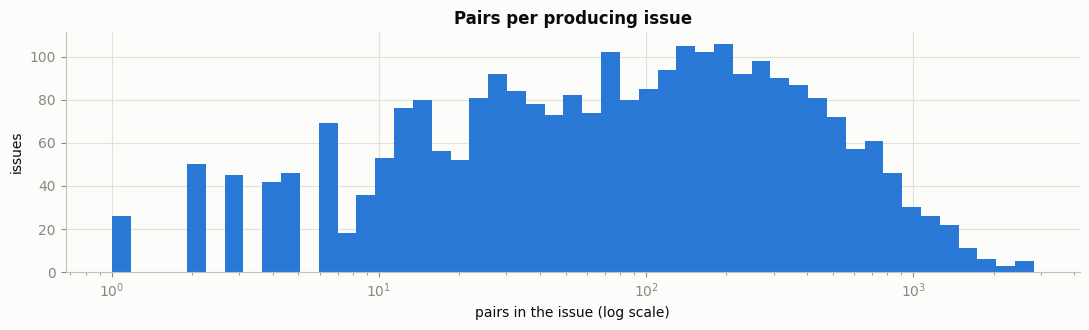

count    2674.0
mean      206.2
std       310.4
min         1.0
10%         7.0
25%        22.0
50%        84.0
75%       260.8
90%       558.0
99%      1439.9
max      2830.0


In [ ]:
per_issue = df.groupby("filename").size()
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.hist(per_issue, bins=np.logspace(0, np.log10(max(per_issue.max(), 10)), 50),
        color=SEQ_BLUE)
ax.set_xscale("log")
ax.set_title("Pairs per producing issue")
ax.set_xlabel("pairs in the issue (log scale)")
ax.set_ylabel("issues")
plt.tight_layout()
plt.show()

print(per_issue.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).round(1).to_string())

### Component types

The matcher gates on *family* (text / table / figure) but scores a family match with a type
mismatch at 0.5 rather than rejecting it, so the two sides are allowed to disagree
(`dataset.py`). The off-diagonal mass below is therefore expected, not a bug — what matters
is whether it is concentrated somewhere odd.

Only the 12-column rows carry these fields.

551,437 rows carry component types (100.0% of the corpus)


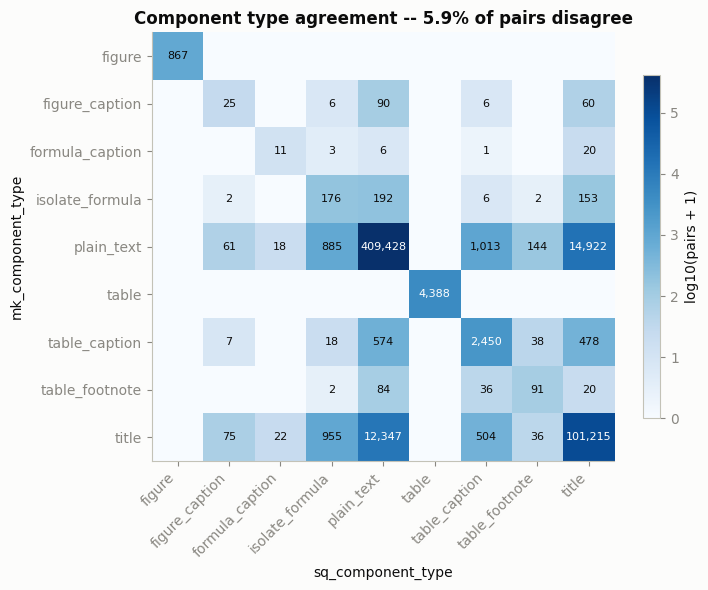

sq_component_type,figure,figure_caption,formula_caption,isolate_formula,plain_text,table,table_caption,table_footnote,title
mk_component_type,,,,,,,,,
figure,867,0,0,0,0,0,0,0,0
figure_caption,0,25,0,6,90,0,6,0,60
formula_caption,0,0,11,3,6,0,1,0,20
isolate_formula,0,2,0,176,192,0,6,2,153
plain_text,0,61,18,885,409428,0,1013,144,14922
table,0,0,0,0,0,4388,0,0,0
table_caption,0,7,0,18,574,0,2450,38,478
table_footnote,0,0,0,2,84,0,36,91,20
title,0,75,22,955,12347,0,504,36,101215


In [ ]:
typed = df[df["mk_component_type"].notna() & df["sq_component_type"].notna()]
print(f"{len(typed):,} rows carry component types ({len(typed) / len(df):.1%} of the corpus)")

if len(typed):
    confusion = pd.crosstab(typed["mk_component_type"], typed["sq_component_type"])
    mismatch = 1 - np.diag(confusion.reindex(index=confusion.columns).fillna(0)).sum() / len(typed)

    fig, ax = plt.subplots(figsize=(7.5, 6))
    image = ax.imshow(np.log10(confusion.to_numpy() + 1), cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(confusion.columns)), confusion.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(confusion.index)), confusion.index)
    ax.set_xlabel("sq_component_type")
    ax.set_ylabel("mk_component_type")
    ax.set_title(f"Component type agreement -- {mismatch:.1%} of pairs disagree")
    ax.grid(False)
    for i in range(confusion.shape[0]):
        for j in range(confusion.shape[1]):
            value = confusion.iat[i, j]
            if value:
                ax.text(j, i, f"{value:,}", ha="center", va="center", fontsize=8,
                        color="white" if np.log10(value + 1) > np.log10(confusion.to_numpy().max() + 1) * 0.6 else INK)
    fig.colorbar(image, ax=ax, label="log10(pairs + 1)", shrink=0.8)
    plt.tight_layout()
    plt.show()
    display(confusion)

,ocr,text_layer,pct_ocr
mk,68327,483110,0.124
sq,81197,470240,0.147


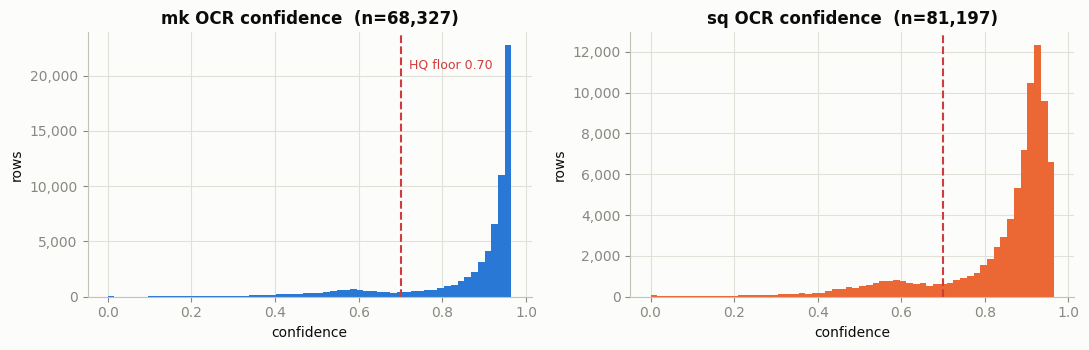

In [ ]:
# OCR vs text layer, per side
ocr_share = pd.DataFrame({
    "ocr": [df["mk_ocr_confidence"].notna().sum(), df["sq_ocr_confidence"].notna().sum()],
    "text_layer": [df["mk_ocr_confidence"].isna().sum(), df["sq_ocr_confidence"].isna().sum()],
}, index=["mk", "sq"])
ocr_share["pct_ocr"] = (ocr_share["ocr"] / len(df)).round(3)
display(ocr_share)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, side, colour in zip(axes, ("mk", "sq"), (SERIES[0], SERIES[1])):
    values = df[f"{side}_ocr_confidence"].dropna()
    ax.hist(values, bins=60, color=colour)
    ax.axvline(PAIR_HQ_MIN_OCR_CONFIDENCE, color=STATUS["critical"], linestyle="--",
               linewidth=1.5)
    ax.set_title(f"{side} OCR confidence  (n={len(values):,})")
    ax.set_xlabel("confidence")
    ax.set_ylabel("rows")
    thousands(ax)
axes[0].text(PAIR_HQ_MIN_OCR_CONFIDENCE, axes[0].get_ylim()[1] * 0.9, "  HQ floor 0.70",
             color=STATUS["critical"], fontsize=9, va="top")
plt.tight_layout()
plt.show()

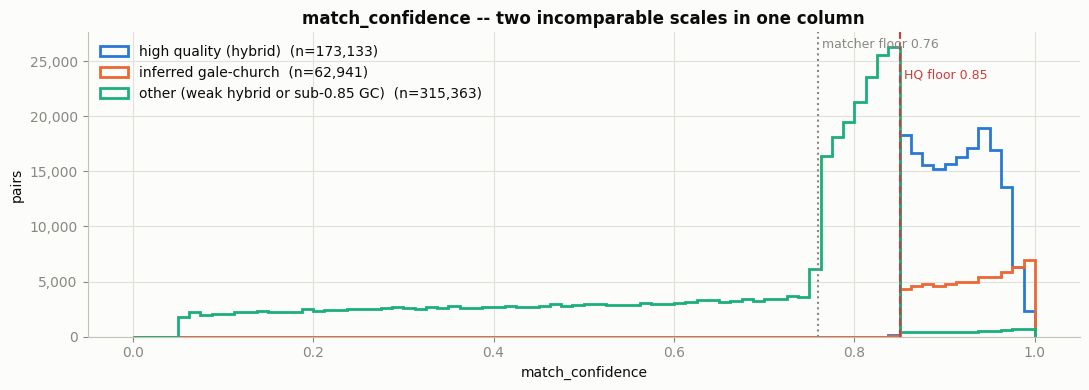

count   mean    std   min    25%    50%    75%  max
is_high_quality gale_church_inferred                                                        
False           False                 315363.0  0.628  0.238  0.05  0.455  0.762  0.814  1.0
                True                   62941.0  0.931  0.044  0.85  0.893  0.934  0.970  1.0
True            False                 173133.0  0.915  0.039  0.85  0.882  0.916  0.948  1.0

In [ ]:
# match_confidence -- remembering that the column mixes two different quantities
groups = [
    ("high quality (hybrid)", df["is_high_quality"], SERIES[0]),
    ("inferred gale-church", df["gale_church_inferred"], SERIES[1]),
    ("other (weak hybrid or sub-0.85 GC)",
     ~df["is_high_quality"] & ~df["gale_church_inferred"], SERIES[2]),
]

fig, ax = plt.subplots(figsize=(11, 4))
bins = np.linspace(0, 1, 81)
for label, mask, colour in groups:
    values = df.loc[mask, "match_confidence"].dropna()
    ax.hist(values, bins=bins, histtype="step", linewidth=2, color=colour,
            label=f"{label}  (n={len(values):,})")
ax.axvline(SEMANTIC_MIN_MATCH_SCORE, color=INK_MUTED, linestyle=":", linewidth=1.5)
ax.axvline(PAIR_HQ_MIN_CONFIDENCE, color=STATUS["critical"], linestyle="--", linewidth=1.5)
ax.set_title("match_confidence -- two incomparable scales in one column")
ax.set_xlabel("match_confidence")
ax.set_ylabel("pairs")
ax.legend(loc="upper left")
thousands(ax)
ax.text(SEMANTIC_MIN_MATCH_SCORE, ax.get_ylim()[1] * 0.98, " matcher floor 0.76",
        color=INK_MUTED, fontsize=9, va="top")
ax.text(PAIR_HQ_MIN_CONFIDENCE, ax.get_ylim()[1] * 0.88, " HQ floor 0.85",
        color=STATUS["critical"], fontsize=9, va="top")
plt.tight_layout()
plt.show()

df.groupby(["is_high_quality", "gale_church_inferred"])["match_confidence"].describe().round(3)

---
## 4. Pair-quality forensics

Everything in this section is vectorised. `slusben_vesnik/language/script.py` classifies
characters with `unicodedata.name()` one at a time — correct, and fine for a single issue,
but hopeless across ~1.1M texts. What follows is a **deliberate reimplementation of the same
classification** as regex character-class counts. It is not a different definition of
"Cyrillic"; it is the same one, computed in bulk.

In [ ]:
CYRILLIC_RE = r"[Ѐ-ӿԀ-ԯ]"
LATIN_RE = r"[A-Za-zÀ-ɏ]"
NUMERIC_RE = r"\d+(?:[./\-]\d+)*"        # verbatim from matching/position.py
NO_EVIDENCE = 0.5                        # score for "this signal cannot speak here"

mk, sq = df["mk_text"], df["sq_text"]

# --- length ------------------------------------------------------------------
df["mk_chars"] = mk.str.len()
df["sq_chars"] = sq.str.len()
df["mk_words"] = mk.str.split().str.len().fillna(0).astype(int)
df["sq_words"] = sq.str.split().str.len().fillna(0).astype(int)

longer = np.maximum(df["mk_chars"], df["sq_chars"])
shorter = np.minimum(df["mk_chars"], df["sq_chars"])
df["length_ratio"] = np.where(longer > 0, shorter / longer, 0.0)

# --- script ------------------------------------------------------------------
mk_cyr, mk_lat = mk.str.count(CYRILLIC_RE), mk.str.count(LATIN_RE)
sq_cyr, sq_lat = sq.str.count(CYRILLIC_RE), sq.str.count(LATIN_RE)
mk_letters, sq_letters = mk_cyr + mk_lat, sq_cyr + sq_lat

# A letterless text (a page number, a bare table cell) gives script no evidence either way,
# so it scores NO_EVIDENCE rather than 0 or 1. Such rows are caught by the length and
# degeneracy checks instead.
df["mk_cyrillic_share"] = np.where(mk_letters > 0, mk_cyr / mk_letters, np.nan)
df["sq_latin_share"] = np.where(sq_letters > 0, sq_lat / sq_letters, np.nan)
df["script_purity"] = (
    df["mk_cyrillic_share"].fillna(NO_EVIDENCE) + df["sq_latin_share"].fillna(NO_EVIDENCE)
) / 2

print(f"mk side that is majority-Latin  : {(df['mk_cyrillic_share'] < 0.5).sum():,}")
print(f"sq side that is majority-Cyrillic: {(df['sq_latin_share'] < 0.5).sum():,}")
print(f"letterless mk / sq              : {mk_letters.eq(0).sum():,} / {sq_letters.eq(0).sum():,}")

mk side that is majority-Latin  : 38
sq side that is majority-Cyrillic: 2
letterless mk / sq              : 214 / 0


In [ ]:
# --- numeric-token agreement --------------------------------------------------
# A translated act keeps its reference number, its dates and its article numbers verbatim
# ("Бр.25-309/1" -> "Nr. 25-309/1"), which makes this the one content signal that crosses
# the language boundary without an encoder.
mk_numbers = mk.str.findall(NUMERIC_RE)
sq_numbers = sq.str.findall(NUMERIC_RE)


def _jaccard(a, b) -> float:
    left, right = set(a), set(b)
    if not left and not right:
        return np.nan               # neither side has numerals: no evidence
    if not left or not right:
        return 0.0                  # one side dropped every numeral: real disagreement
    return len(left & right) / len(left | right)


df["numeric_overlap_raw"] = [
    _jaccard(a, b) for a, b in zip(mk_numbers, sq_numbers)
]
df["numeric_overlap"] = df["numeric_overlap_raw"].fillna(NO_EVIDENCE)

del mk_numbers, sq_numbers          # 551k lists of strings; Colab wants the RAM back

no_numbers = df["numeric_overlap_raw"].isna().sum()
print(f"rows with no numerals on either side : {no_numbers:,} ({no_numbers / len(df):.1%})")
print(f"rows where numerals fully agree      : {(df['numeric_overlap_raw'] == 1).sum():,}")
print(f"rows where numerals fully disagree   : {(df['numeric_overlap_raw'] == 0).sum():,}")
df["numeric_overlap_raw"].describe().round(3)

rows with no numerals on either side : 124,255 (22.5%)
rows where numerals fully agree      : 243,705
rows where numerals fully disagree   : 93,368


,numeric_overlap_raw
count,427182.000
mean,0.686
std,0.415
min,0.000
25%,0.333
50%,1.000
75%,1.000
max,1.000


In [ ]:
# --- degeneracy and copy-through ---------------------------------------------
def _normalise(series: pd.Series) -> pd.Series:
    return (series.str.casefold()
                  .str.replace(r"[^\w\s]", "", regex=True)
                  .str.replace(r"\s+", " ", regex=True)
                  .str.strip())


mk_norm, sq_norm = _normalise(mk), _normalise(sq)

df["mk_empty"] = mk.str.strip() == ""
df["sq_empty"] = sq.str.strip() == ""
df["either_empty"] = df["mk_empty"] | df["sq_empty"]
df["very_short"] = (df["mk_chars"] < 20) | (df["sq_chars"] < 20)
df["no_letters"] = (mk_letters == 0) | (sq_letters == 0)
df["copy_through"] = (mk == sq) & ~df["either_empty"]
df["copy_through_norm"] = (mk_norm == sq_norm) & ~df["either_empty"]

degeneracy = pd.DataFrame({
    "rows": [df[c].sum() for c in
             ("mk_empty", "sq_empty", "either_empty", "very_short", "no_letters",
              "copy_through", "copy_through_norm")],
}, index=["mk empty", "sq empty", "either empty", "a side under 20 chars",
          "a side with no letters", "identical text", "identical after normalising"])
degeneracy["pct"] = (degeneracy["rows"] / len(df)).map(lambda v: f"{v:.2%}")
degeneracy["pct of HQ"] = [
    f"{(df[c] & df['is_high_quality']).sum() / max(int(df['is_high_quality'].sum()), 1):.2%}"
    for c in ("mk_empty", "sq_empty", "either_empty", "very_short", "no_letters",
              "copy_through", "copy_through_norm")
]
degeneracy

,rows,pct,pct of HQ
mk empty,0,0.00%,0.00%
sq empty,0,0.00%,0.00%
either empty,0,0.00%,0.00%
a side under 20 chars,88841,16.11%,18.79%
a side with no letters,214,0.04%,0.00%
identical text,0,0.00%,0.00%
identical after normalising,0,0.00%,0.00%


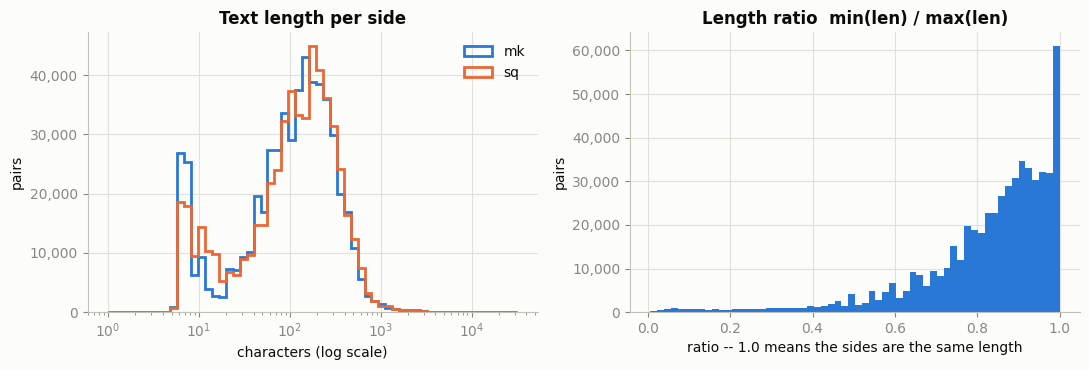

,mk_chars,sq_chars,length_ratio
count,551437.00,551437.00,551437.00
mean,164.86,171.40,0.83
std,211.65,211.55,0.17
min,5.00,5.00,0.01
1%,6.00,6.00,0.15
5%,6.00,7.00,0.50
25%,51.00,51.00,0.77
50%,121.00,123.00,0.87
75%,222.00,231.00,0.94
95%,452.00,474.00,1.00


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(df.loc[df["mk_chars"] > 0, "mk_chars"], bins=np.logspace(0, 4.5, 60),
             histtype="step", linewidth=2, color=SERIES[0], label="mk")
axes[0].hist(df.loc[df["sq_chars"] > 0, "sq_chars"], bins=np.logspace(0, 4.5, 60),
             histtype="step", linewidth=2, color=SERIES[1], label="sq")
axes[0].set_xscale("log")
axes[0].set_title("Text length per side")
axes[0].set_xlabel("characters (log scale)")
axes[0].set_ylabel("pairs")
axes[0].legend()
thousands(axes[0])

axes[1].hist(df["length_ratio"], bins=60, color=SEQ_BLUE)
axes[1].set_title("Length ratio  min(len) / max(len)")
axes[1].set_xlabel("ratio -- 1.0 means the sides are the same length")
axes[1].set_ylabel("pairs")
thousands(axes[1])
plt.tight_layout()
plt.show()

df[["mk_chars", "sq_chars", "length_ratio"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).round(2)

### Independent language check

`lingua` is asked the question the pipeline's own language stage already answered, so a
disagreement is a real signal rather than a restatement. It is restricted to the four
languages that plausibly appear (Macedonian, Albanian, Serbian, English) and run in
low-accuracy mode on the first 300 characters.

**Detection runs on distinct texts, not on rows.** Gazette boilerplate repeats heavily, so
the number of strings to classify is far below the 1.1M texts in the corpus. Results are
cached back into the consolidated file, so this cell is paid for once.

In [ ]:
from lingua import Language, LanguageDetectorBuilder

LINGUA_SNIPPET = 300
LINGUA_MIN_CHARS = 15
LINGUA_LANGUAGES = [
    Language.MACEDONIAN, Language.ALBANIAN, Language.SERBIAN, Language.ENGLISH,
]

# Serbian shares the Cyrillic alphabet with Macedonian and is the standing confusion, so a
# Serbian verdict on the mk side is a soft signal, not a hard failure. Anything else is.
MK_EXPECTED = {"MACEDONIAN": 1.0, "SERBIAN": 0.4}
SQ_EXPECTED = {"ALBANIAN": 1.0}

_detector = (
    LanguageDetectorBuilder.from_languages(*LINGUA_LANGUAGES)
    .with_low_accuracy_mode()
    .build()
)


def detect_unique(texts: list, chunk: int = 20_000) -> dict:
    '''language name (or None) for each distinct text, detected once per string.'''
    verdicts = {}
    parallel = getattr(_detector, "detect_languages_in_parallel_of", None)
    t0 = time.time()
    for start in range(0, len(texts), chunk):
        batch = texts[start:start + chunk]
        results = parallel(batch) if parallel else [_detector.detect_language_of(t) for t in batch]
        verdicts.update({t: (r.name if r is not None else None) for t, r in zip(batch, results)})
        done = min(start + chunk, len(texts))
        print(f"  {done:>8,}/{len(texts):,}  ({done / max(time.time() - t0, 1e-9):,.0f} texts/s)")
    return verdicts


snippet_mk = mk.str.slice(0, LINGUA_SNIPPET)
snippet_sq = sq.str.slice(0, LINGUA_SNIPPET)

distinct = pd.unique(pd.concat([snippet_mk, snippet_sq], ignore_index=True))
distinct = [t for t in distinct if len(t.strip()) >= LINGUA_MIN_CHARS]
print(f"{len(distinct):,} distinct texts to classify "
      f"(vs {2 * len(df):,} texts in the corpus -- "
      f"{1 - len(distinct) / max(2 * len(df), 1):.1%} saved by deduplicating)")

verdicts = detect_unique(distinct)
df["mk_language"] = snippet_mk.map(verdicts)
df["sq_language"] = snippet_sq.map(verdicts)
del verdicts, distinct

684,167 distinct texts to classify (vs 1,102,874 texts in the corpus -- 38.0% saved by deduplicating)
    20,000/684,167  (4,789 texts/s)
    40,000/684,167  (4,718 texts/s)
    60,000/684,167  (4,190 texts/s)
    80,000/684,167  (4,370 texts/s)
   100,000/684,167  (4,456 texts/s)
   120,000/684,167  (4,253 texts/s)
   140,000/684,167  (4,327 texts/s)
   160,000/684,167  (4,394 texts/s)
   180,000/684,167  (4,268 texts/s)
   200,000/684,167  (4,301 texts/s)
   220,000/684,167  (4,328 texts/s)
   240,000/684,167  (4,220 texts/s)
   260,000/684,167  (4,241 texts/s)
   280,000/684,167  (4,246 texts/s)
   300,000/684,167  (4,174 texts/s)
   320,000/684,167  (4,195 texts/s)
   340,000/684,167  (4,282 texts/s)
   360,000/684,167  (4,305 texts/s)
   380,000/684,167  (4,416 texts/s)
   400,000/684,167  (4,518 texts/s)
   420,000/684,167  (4,604 texts/s)
   440,000/684,167  (4,671 texts/s)
   460,000/684,167  (4,696 texts/s)
   480,000/684,167  (4,790 texts/s)
   500,000/684,167  (4,872 texts/s

mk side detected as:
mk_language
MACEDONIAN    81.89%
NaN           13.31%
SERBIAN        4.32%
ALBANIAN       0.25%
None           0.21%
ENGLISH        0.02%

sq side detected as:
sq_language
ALBANIAN      78.28%
NaN           13.62%
ENGLISH        7.35%
MACEDONIAN     0.27%
SERBIAN        0.24%
None           0.24%

both sides as expected (MK + SQ): 404,872 (73.4%)
  ... within is_high_quality    : 78.3%


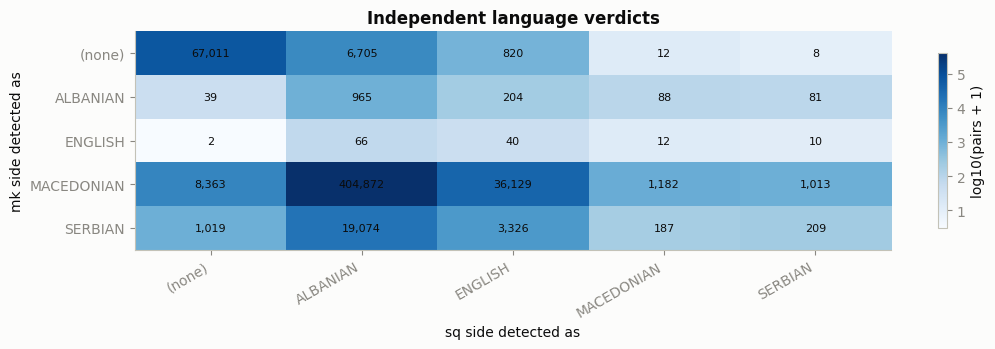

In [ ]:
df["mk_language_score"] = df["mk_language"].map(MK_EXPECTED).where(
    df["mk_language"].notna(), NO_EVIDENCE
).fillna(0.0)
df["sq_language_score"] = df["sq_language"].map(SQ_EXPECTED).where(
    df["sq_language"].notna(), NO_EVIDENCE
).fillna(0.0)
df["lingua_agreement"] = (df["mk_language_score"] + df["sq_language_score"]) / 2

print("mk side detected as:")
print((df["mk_language"].value_counts(dropna=False) / len(df)).map(lambda v: f"{v:.2%}").to_string())
print("\nsq side detected as:")
print((df["sq_language"].value_counts(dropna=False) / len(df)).map(lambda v: f"{v:.2%}").to_string())

expected_pair = (df["mk_language"] == "MACEDONIAN") & (df["sq_language"] == "ALBANIAN")
print(f"\nboth sides as expected (MK + SQ): {expected_pair.sum():,} ({expected_pair.mean():.1%})")
print(f"  ... within is_high_quality    : "
      f"{(expected_pair & df['is_high_quality']).sum() / max(int(df['is_high_quality'].sum()), 1):.1%}")

fig, ax = plt.subplots(figsize=(11, 3.6))
cross = pd.crosstab(df["mk_language"].fillna("(none)"), df["sq_language"].fillna("(none)"))
image = ax.imshow(np.log10(cross.to_numpy() + 1), cmap="Blues", aspect="auto")
ax.set_xticks(range(len(cross.columns)), cross.columns, rotation=30, ha="right")
ax.set_yticks(range(len(cross.index)), cross.index)
ax.set_xlabel("sq side detected as")
ax.set_ylabel("mk side detected as")
ax.set_title("Independent language verdicts")
ax.grid(False)
for i in range(cross.shape[0]):
    for j in range(cross.shape[1]):
        if cross.iat[i, j]:
            ax.text(j, i, f"{cross.iat[i, j]:,}", ha="center", va="center", fontsize=8, color=INK)
fig.colorbar(image, ax=ax, label="log10(pairs + 1)", shrink=0.8)
plt.tight_layout()
plt.show()

---
## 5. `quality_confidence`

A **new** column. `is_high_quality` is kept exactly as the pipeline wrote it — the two
answer different questions, and the boolean is the one that is reproducible from
`config.py` thresholds.

    match_term   = ramp(match_confidence, 0.76 -> 0.95)
    ocr_term     = ramp(min(mk_ocr, sq_ocr), 0.50 -> 0.85)      # both null => 1.0
    method_term  = 1.0 hybrid | 0.35 inferred gale-church
    nonempty     = 0.0 if either side is blank
    matcher_term = match_term * ocr_term * method_term * nonempty

    text_term    = 0.35*numeric_overlap + 0.30*lingua_agreement
                 + 0.20*script_purity   + 0.15*length_ratio

    quality_confidence = sqrt(matcher_term * text_term)

`ramp(x, lo, hi) = clip((x - lo) / (hi - lo), 0, 1)` is the same shape `matching/hybrid.py`
already uses for its semantic term.

Two design choices worth stating:

* **The geometric mean, not the arithmetic one.** A pair that the matcher likes but whose
  texts are not plausibly a translation should not average out to "medium". Either term
  near zero drags the score down.
* **`length_ratio` is the lightest text weight.** For every Gale-Church row,
  `match_confidence` *is* a length statistic, so weighting length heavily would count the
  same evidence twice. The two signals that genuinely cross the language boundary —
  shared numerals and the language verdict — carry most of the weight.

In [ ]:
def ramp(values, low: float, high: float):
    '''clip((x - low) / (high - low), 0, 1) -- the shape matching/hybrid.py uses.'''
    return np.clip((np.asarray(values, dtype=float) - low) / (high - low), 0.0, 1.0)


match_term = ramp(df["match_confidence"].fillna(0.0), *MATCH_RAMP)

ocr_min = df[["mk_ocr_confidence", "sq_ocr_confidence"]].min(axis=1)   # skips nulls
ocr_term = np.where(ocr_min.isna(), 1.0, ramp(ocr_min.fillna(1.0), *OCR_RAMP))

method_term = np.where(df["gale_church_inferred"], GALE_CHURCH_PENALTY, 1.0)
nonempty = np.where(df["either_empty"], 0.0, 1.0)

df["matcher_term"] = match_term * ocr_term * method_term * nonempty
df["text_term"] = sum(weight * df[name] for name, weight in TEXT_WEIGHTS.items())
df["quality_confidence"] = np.sqrt(df["matcher_term"] * df["text_term"])

assert df["quality_confidence"].between(0, 1).all(), "score escaped [0, 1]"
assert df["quality_confidence"].notna().all(), "score has NaN"

print(df[["matcher_term", "text_term", "quality_confidence"]].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(3).to_string())

       matcher_term   text_term  quality_confidence
count    551437.000  551437.000          551437.000
mean          0.356       0.810               0.443
std           0.342       0.159               0.350
min           0.000       0.180               0.000
5%            0.000       0.482               0.000
25%           0.000       0.722               0.000
50%           0.297       0.819               0.463
75%           0.605       0.966               0.744
95%           1.000       0.994               0.990
max           1.000       1.000               1.000


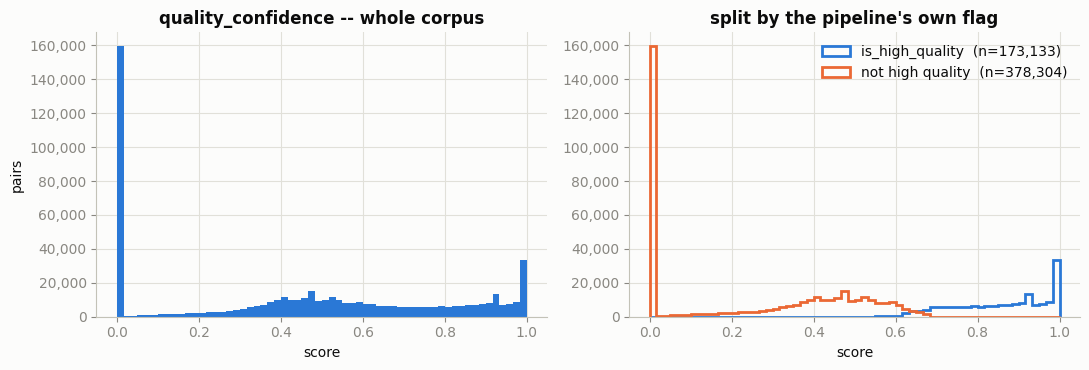

,count,mean,std,min,5%,10%,50%,90%,max
is_high_quality,,,,,,,,,
False,378304.0,0.252,0.238,0.000,0.000,0.000,0.286,0.564,0.731
True,173133.0,0.859,0.113,0.449,0.659,0.691,0.881,0.994,1.000


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
bins = np.linspace(0, 1, 61)
axes[0].hist(df["quality_confidence"], bins=bins, color=SEQ_BLUE)
axes[0].set_title("quality_confidence -- whole corpus")
axes[0].set_xlabel("score")
axes[0].set_ylabel("pairs")
thousands(axes[0])

for label, mask, colour in (("is_high_quality", df["is_high_quality"], SERIES[0]),
                            ("not high quality", ~df["is_high_quality"], SERIES[1])):
    axes[1].hist(df.loc[mask, "quality_confidence"], bins=bins, histtype="step",
                 linewidth=2, color=colour, label=f"{label}  (n={int(mask.sum()):,})")
axes[1].set_title("split by the pipeline's own flag")
axes[1].set_xlabel("score")
axes[1].legend()
thousands(axes[1])
plt.tight_layout()
plt.show()

df.groupby("is_high_quality")["quality_confidence"].describe(
    percentiles=[0.05, 0.1, 0.5, 0.9]).round(3)

### Calibration

Two questions. *Does the score agree with the flag?* — if it disagreed wildly, one of them
is wrong. And *what does a threshold cost?* — the volume/quality trade-off, which is the
number anyone building a training set actually needs.

threshold that best reproduces is_high_quality: 0.64 (agreement 97.9%, 175,015 rows kept)


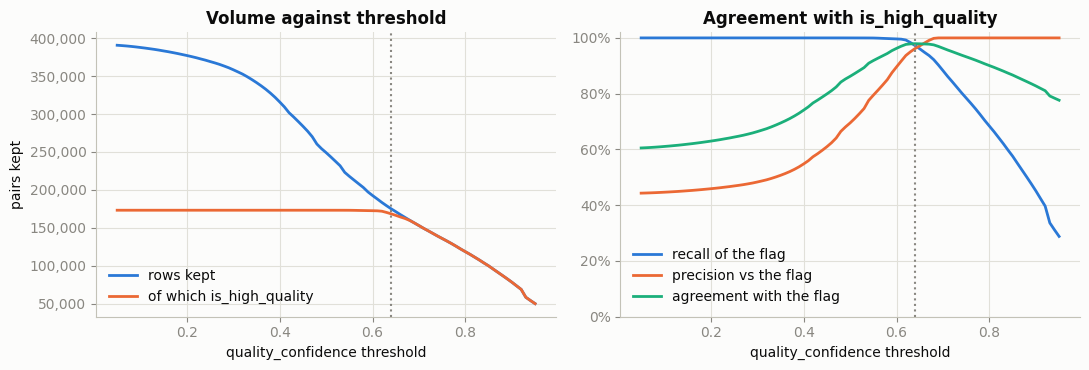

,rows_kept,pct_kept,hq_kept,hq_recall,precision_vs_flag,agreement
threshold,,,,,,
0.2,377340,0.684,173133,1.000,0.459,0.630
0.3,358545,0.650,173133,1.000,0.483,0.664
0.4,316007,0.573,173133,1.000,0.548,0.741
0.5,249121,0.452,173119,1.000,0.695,0.862
0.6,192516,0.349,172503,0.996,0.896,0.963
0.7,152794,0.277,152792,0.883,1.000,0.963
0.8,118316,0.215,118316,0.683,1.000,0.901


In [ ]:
thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)
score = df["quality_confidence"].to_numpy()
flag = df["is_high_quality"].to_numpy()

rows = []
for t in thresholds:
    keep = score >= t
    true_pos = int((keep & flag).sum())
    rows.append({
        "threshold": t,
        "rows_kept": int(keep.sum()),
        "pct_kept": keep.mean(),
        "hq_kept": true_pos,
        "hq_recall": true_pos / max(int(flag.sum()), 1),
        "precision_vs_flag": true_pos / max(int(keep.sum()), 1),
        "agreement": float((keep == flag).mean()),
    })
sweep = pd.DataFrame(rows).set_index("threshold")

best = sweep["agreement"].idxmax()
print(f"threshold that best reproduces is_high_quality: {best:.2f} "
      f"(agreement {sweep.loc[best, 'agreement']:.1%}, "
      f"{sweep.loc[best, 'rows_kept']:,} rows kept)")

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.8))
left.plot(sweep.index, sweep["rows_kept"], color=SERIES[0], label="rows kept")
left.plot(sweep.index, sweep["hq_kept"], color=SERIES[1], label="of which is_high_quality")
left.axvline(best, color=INK_MUTED, linestyle=":", linewidth=1.5)
left.set_title("Volume against threshold")
left.set_xlabel("quality_confidence threshold")
left.set_ylabel("pairs kept")
left.legend()
thousands(left)

right.plot(sweep.index, sweep["hq_recall"], color=SERIES[0], label="recall of the flag")
right.plot(sweep.index, sweep["precision_vs_flag"], color=SERIES[1], label="precision vs the flag")
right.plot(sweep.index, sweep["agreement"], color=SERIES[2], label="agreement with the flag")
right.axvline(best, color=INK_MUTED, linestyle=":", linewidth=1.5)
right.set_title("Agreement with is_high_quality")
right.set_xlabel("quality_confidence threshold")
right.set_ylim(0, 1.02)
right.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
right.legend(loc="lower left")
plt.tight_layout()
plt.show()

sweep.loc[[0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]].round(3)

In [ ]:
# where the two disagree -- these are the rows worth eyeballing
scored_high_flag_low = df[(df["quality_confidence"] >= best) & ~df["is_high_quality"]]
scored_low_flag_high = df[(df["quality_confidence"] < best) & df["is_high_quality"]]
print(f"score says keep, flag says no : {len(scored_high_flag_low):,} "
      f"({len(scored_high_flag_low) / len(df):.1%}) -- mostly the Gale-Church penalty")
print(f"flag says keep, score says no : {len(scored_low_flag_high):,} "
      f"({len(scored_low_flag_high) / len(df):.1%}) -- the text signals object")

if len(scored_low_flag_high):
    print("\nthe flag's own rows that the text signals reject, worst first:")
    columns = ["quality_confidence", "match_confidence", "length_ratio", "script_purity",
               "lingua_agreement", "numeric_overlap", "mk_text", "sq_text"]
    preview = scored_low_flag_high.nsmallest(8, "quality_confidence")[columns].copy()
    for side in ("mk_text", "sq_text"):
        preview[side] = preview[side].str.slice(0, 70)
    display(preview.round(3))

score says keep, flag says no : 6,657 (1.2%) -- mostly the Gale-Church penalty
flag says keep, score says no : 4,775 (0.9%) -- the text signals object

the flag's own rows that the text signals reject, worst first:


,quality_confidence,match_confidence,length_ratio,script_purity,lingua_agreement,numeric_overlap,mk_text,sq_text
296618,0.449,0.856,0.424,0.929,0.25,1.000,"3. „ со ЕМБГ ,","3. , мат Passport No. ID number ,"
90441,0.457,0.859,0.987,0.511,0.50,0.000,прилог 19 ВЕТЕРИНАРНО САНИТАРЕН СЕРТИФИКАТ Hea...,ВЕТЕРИНАРНО САНИТАРЕН СЕРТИФИКАТ Health Certif...
32565,0.476,0.873,0.957,0.511,0.50,0.625,ПОДАТОЦИ ЗА ПРВАТА РЕГИСТРАЦИЈА ХА TË DHËNA PË...,TË DHËNA PËR REGJISTRIMIN E PARË НА тој ДАТУМ ...
277867,0.480,0.870,0.954,0.523,0.50,0.000,НОСИТЕЛОТ НА ОВАА ЛИЧНА КАРТА E ОСЛОБОДЕН ОД О...,НОСИТЕЛОТ НА ОВАА ЛИЧНА КАРТА Е ОСЛОБОДЕН ОД О...
148569,0.483,0.855,0.778,1.000,0.50,1.000,Член 11,Craten 11
39248,0.483,0.875,0.903,0.536,0.50,0.750,Членови: Uyeler: 1. 2. 3. 4.,Членови: Uyeler: 1. 2. GJ 4. |.
416078,0.487,0.856,0.667,1.000,0.50,1.000,Член 2,Article 2
36978,0.487,0.867,0.368,0.958,0.25,1.000,АММЕХ 4,(vYhite paper — А4)


In [ ]:
# stratified sample across deciles, for manual review
rng = np.random.default_rng(20260909)
df["quality_decile"] = pd.cut(df["quality_confidence"], np.linspace(0, 1, 11),
                              include_lowest=True, labels=[f"{i / 10:.1f}-{(i + 1) / 10:.1f}"
                                                           for i in range(10)])
per_decile = 20
# built group by group rather than with groupby.apply, which drops the grouping column
sample = pd.concat(
    [group.sample(min(len(group), per_decile), random_state=42)
     for _, group in df.groupby("quality_decile", observed=True)]
)
sample_columns = [
    "slv_identifier", "filename", "year", "quality_decile", "quality_confidence",
    "is_high_quality", "gale_church_inferred", "match_confidence",
    "length_ratio", "script_purity", "lingua_agreement", "numeric_overlap",
    "mk_language", "sq_language", "mk_text", "sq_text",
]
sample_out = sample[sample_columns].sort_values("quality_confidence", ascending=False)

sample_path = (LOCAL_OUT_DIR / "quality_sample.csv") if LOCAL_SMOKE_TEST else Path("quality_sample.csv")
sample_out.to_csv(sample_path, index=False)
print(f"{len(sample_out)} pairs written to {sample_path} for manual review")
sample_out.head(10)

200 pairs written to quality_sample.csv for manual review


,slv_identifier,filename,year,quality_decile,quality_confidence,is_high_quality,gale_church_inferred,match_confidence,length_ratio,script_purity,lingua_agreement,numeric_overlap,mk_language,sq_language,mk_text,sq_text
186467,2014-2-14,a5ab626b2a9e49faa30af917fd54838f__СЛУЖБЕН_ВЕСН...,2014,0.9-1.0,0.999366,True,False,0.9710,0.991549,1.0,1.0,1.0,MACEDONIAN,ALBANIAN,у „9) донесува акти за внатрешна организација ...,"y j ""9) miraton akte për organizim të brendshë..."
311701,2021-7-8,677f083b03684b7a9edaf214103c4887__СЛУЖБЕН_ВЕСН...,2021,0.9-1.0,0.997982,True,False,0.9619,0.973118,1.0,1.0,1.0,MACEDONIAN,ALBANIAN,р д ј Во став (2) во алинејата 3 зборовите: „И...,q Në paragrafin (2) nënparagrafi 3 fjalët: “In...
188621,2014-3-3,044cf486042c488bbc2f0163352cdd2e__СЛУЖБЕН_ВЕСН...,2014,0.9-1.0,0.990506,True,False,0.9507,0.874016,1.0,1.0,1.0,MACEDONIAN,ALBANIAN,( ) у „За член на Државната комисија може да б...,"g ( ) y j ""Anëtar i Komisionit shtetëror mund ..."
214345,2015-8-9,b5789edcde6941778f233b5029e84311__СЛУЖБЕН_ВЕСН...,2015,0.9-1.0,0.990501,True,False,0.9578,0.873950,1.0,1.0,1.0,MACEDONIAN,ALBANIAN,(1) За прекршоците утврдени во членовите 40 и ...,(1) Për kundërvajtjet e përcaktuara në nenet 4...
513826,2025-12-6,aa268f5ef028435bb95884424cad7735__СЛУЖБЕН_ВЕСН...,2025,0.9-1.0,0.988721,True,False,0.9633,0.850467,1.0,1.0,1.0,MACEDONIAN,ALBANIAN,д 3. Оваа одлука влегува во сила со денот на д...,j g 3. Ky vendim hyn në fuqi në ditën e sjellj...
180532,2014-12-15,1eea0332a4d94deba4b3b88e996bc996__СЛУЖБЕН_ВЕСН...,2014,0.9-1.0,0.981773,True,False,0.9453,0.922179,1.0,1.0,1.0,MACEDONIAN,ALBANIAN,(1) Националната библиотека води евиденција за...,Ne (1) Biblioteka Nacionale mban evidencë për ...
335169,2022-12-13,3f397679ef3d4195999df40c3b10be49__СЛУЖБЕН_ВЕСН...,2022,0.9-1.0,0.963596,True,False,0.9412,0.824074,1.0,1.0,1.0,MACEDONIAN,ALBANIAN,ц р Дру 2. Издавачот на долгорочни хартии од в...,Kuvendi i Aksionarëve të Shoqërisë. 2. Emetues...
78697,2008-7-6,ED8DC7AF8F917D4B9704F49E8EFCD0DB__СЛУЖБЕН_ВЕСН...,2008,0.9-1.0,0.956230,True,False,0.9405,0.750000,1.0,1.0,1.0,MACEDONIAN,ALBANIAN,години. За прекршокот од ставот 1 на овој член...,gjashtë muaj deri në dy vjet. Për kundërvajtje...
458529,2024-2-17,b7401a8b34154fefb2f6f645a3a5bada__СЛУЖБЕН_ВЕСН...,2024,0.9-1.0,0.944156,True,False,0.9317,0.909605,1.0,1.0,1.0,MACEDONIAN,ALBANIAN,1. Во Одлуката за издавање на лиценца за вршењ...,1. Në Vendimin për Dhënien e Licencës për Usht...
352435,2022-6-7,a1ca8a3cad274409bd60d19fecce89a6__СЛУЖБЕН_ВЕСН...,2022,0.9-1.0,0.937803,True,False,0.9271,1.000000,1.0,1.0,1.0,MACEDONIAN,ALBANIAN,е) проценет животен век на ФЕЦ: 30 години,f) jetëgjatësia e paraparë e CED: 30 vite


---
## 6. Duplicate flagging

**Flag, never drop.** A gazette repeats its own boilerplate relentlessly — the same
enacting formula, the same ministry footer, the same table headers — and some of those
repeats are legitimately good training pairs. Removing them here would be a decision made
in the wrong place. The deduplicated view is one filter away: `df[df.dup_rank == 1]`.

The canonical member of a duplicate group (`dup_rank == 1`) is its highest-scoring row, so
keeping rank 1 keeps the best copy rather than an arbitrary one.

In [ ]:
combined_key = mk_norm + "\x1f" + sq_norm
df["dup_key"] = [hashlib.sha1(text.encode("utf-8")).hexdigest()[:16] for text in combined_key]
df["dup_group_id"] = pd.factorize(df["dup_key"])[0]
df["dup_count"] = df.groupby("dup_key")["dup_key"].transform("size")

ordered = df.sort_values(
    ["dup_key", "quality_confidence", "filename", "slv_identifier"],
    ascending=[True, False, True, True],
)
df["dup_rank"] = ordered.groupby("dup_key").cumcount().add(1).reindex(df.index)

assert (df.loc[df["dup_rank"] == 1, "dup_group_id"].nunique()
        == df["dup_group_id"].nunique()), "not exactly one canonical row per group"
assert (df.groupby("dup_group_id")["dup_rank"].max() == df.groupby("dup_group_id").size()).all()

unique_pairs = int((df["dup_rank"] == 1).sum())
print(f"rows                : {len(df):,}")
print(f"distinct pairs      : {unique_pairs:,} ({unique_pairs / len(df):.1%})")
print(f"duplicate rows      : {len(df) - unique_pairs:,}")
print(f"largest group       : {int(df['dup_count'].max()):,} copies")
print(f"\nwithin is_high_quality: "
      f"{int((df['is_high_quality'] & (df['dup_rank'] == 1)).sum()):,} distinct "
      f"of {int(df['is_high_quality'].sum()):,} rows "
      f"({(df['is_high_quality'] & (df['dup_rank'] == 1)).sum() / max(int(df['is_high_quality'].sum()), 1):.1%})")

rows                : 551,437
distinct pairs      : 419,784 (76.1%)
duplicate rows      : 131,653
largest group       : 2,369 copies

within is_high_quality: 119,692 distinct of 173,133 rows (69.1%)


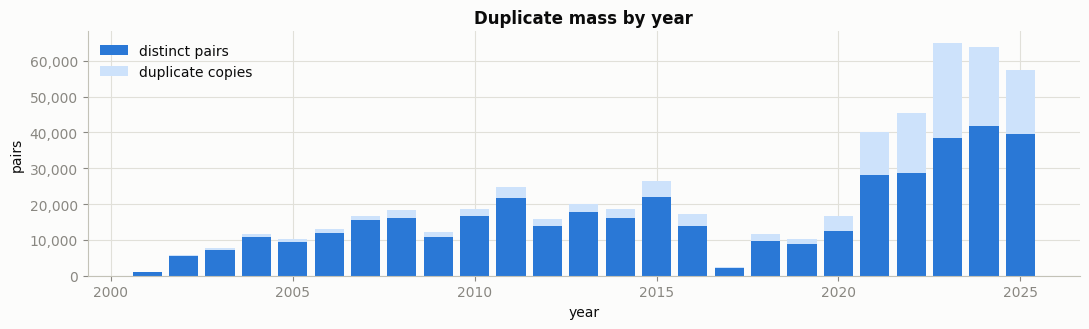

,rows,distinct,duplicate_share
year,,,
2001,1159,1157,0.002
2002,5875,5578,0.051
2003,7622,7066,0.073
2004,11611,10790,0.071
2005,10292,9532,0.074
2006,12966,12049,0.071
2007,16714,15421,0.077
2008,18348,16134,0.121
2009,12313,10787,0.124


In [ ]:
dup_by_year = df.groupby("year").agg(
    rows=("dup_rank", "size"),
    distinct=("dup_rank", lambda s: int((s == 1).sum())),
)
dup_by_year["duplicate_share"] = 1 - dup_by_year["distinct"] / dup_by_year["rows"]

fig, ax = plt.subplots(figsize=(11, 3.4))
years = dup_by_year.index.astype(int)
ax.bar(years, dup_by_year["distinct"], color=SEQ_BLUE, label="distinct pairs")
ax.bar(years, dup_by_year["rows"] - dup_by_year["distinct"],
       bottom=dup_by_year["distinct"], color="#cde2fb", label="duplicate copies")
ax.set_title("Duplicate mass by year")
ax.set_xlabel("year")
ax.set_ylabel("pairs")
ax.legend(loc="upper left")
thousands(ax)
plt.tight_layout()
plt.show()

dup_by_year.round(3)

In [ ]:
# the boilerplate itself
biggest = (
    df[df["dup_rank"] == 1]
    .nlargest(12, "dup_count")[["dup_count", "quality_confidence", "is_high_quality",
                                "mk_text", "sq_text"]]
    .copy()
)
for side in ("mk_text", "sq_text"):
    biggest[side] = biggest[side].str.slice(0, 90).str.replace(r"\s+", " ", regex=True)
biggest.round(3)

,dup_count,quality_confidence,is_high_quality,mk_text,sq_text
314639,2369,0.922,True,Член 1,Neni 1
27872,2170,0.922,True,Член 2,Neni 2
200637,2077,0.922,True,Член 3,Neni 3
69416,1927,0.922,True,Член 4,Neni 4
69418,1551,0.922,True,Член 5,Neni 5
27885,1383,0.922,True,Член 6,Neni 6
27887,1153,0.922,True,Член 7,Neni 7
314651,1090,0.922,True,Член 8,Neni 8
392517,1076,0.999,True,2. Енергетска дејност за која се издава лиценц...,"2. Veprimtaria energjetike, për të cilën jepet..."
314655,937,0.922,True,Член 9,Neni 9


---
## 7. Issue-disjoint train / dev / test split

A random *row* split would put copies of the same boilerplate on both sides of the
train/eval boundary, and any BLEU or chrF measured against it would be measuring
memorisation. The fix is to split on the issue, and the stable issue key is `filename` —
**not** `slv_identifier`, which is a creation-time rank that renumbers when an old PDF is
re-uploaded.

The assignment is a hash of the filename rather than a shuffle, so it is reproducible with
no stored state and stays stable when new issues are added to the bucket later.

In [ ]:
# how bad would a naive random row split be?
group_issue_span = df.groupby("dup_group_id")["filename"].nunique()
cross_issue_groups = int((group_issue_span > 1).sum())
rows_at_risk = int(df["dup_group_id"].map(group_issue_span).gt(1).sum())
print(f"duplicate groups spanning more than one issue: {cross_issue_groups:,}")
print(f"rows in them: {rows_at_risk:,} ({rows_at_risk / len(df):.1%} of the corpus)")
print("Under a random row split every one of those rows is a coin-flip to leak.")

duplicate groups spanning more than one issue: 15,464
rows in them: 141,190 (25.6% of the corpus)
Under a random row split every one of those rows is a coin-flip to leak.


,issues,pairs,high_quality,mean_quality,distinct_pairs,pct_of_pairs,hq_rate
split,,,,,,,
dev,107,24657,8111,0.455,19130,0.045,0.329
test,104,18634,6478,0.459,14057,0.034,0.348
train,2463,508146,158544,0.441,386597,0.921,0.312


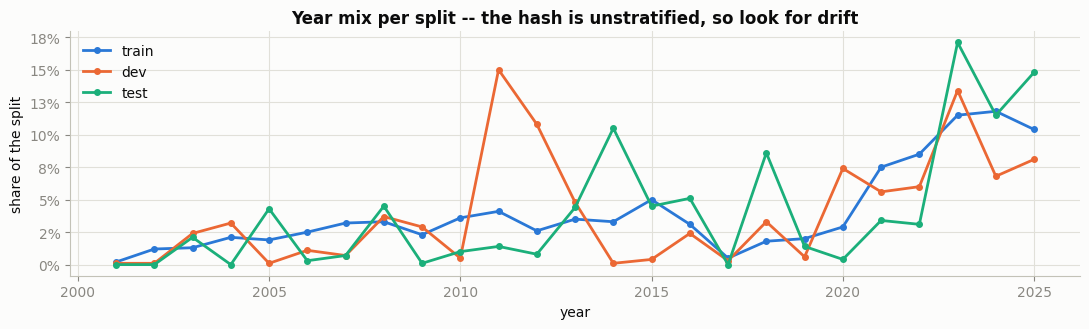

In [ ]:
def split_bucket(name: str) -> int:
    return int(hashlib.sha1(name.encode("utf-8")).hexdigest()[:8], 16) % 100


bucket_of_issue = {name: split_bucket(name) for name in df["filename"].dropna().unique()}
df["split_bucket"] = df["filename"].map(bucket_of_issue).astype("Int16")
df["split"] = np.select(
    [df["split_bucket"].between(lo, hi - 1) for lo, hi in SPLIT_BOUNDS.values()],
    list(SPLIT_BOUNDS.keys()),
    default="train",
)

issues_per_split = df.groupby("split")["filename"].nunique()
assert issues_per_split.sum() == df["filename"].nunique(), "an issue landed in two splits"

profile = df.groupby("split").agg(
    issues=("filename", "nunique"),
    pairs=("split", "size"),
    high_quality=("is_high_quality", "sum"),
    mean_quality=("quality_confidence", "mean"),
    distinct_pairs=("dup_rank", lambda s: int((s == 1).sum())),
)
profile["pct_of_pairs"] = (profile["pairs"] / len(df)).round(3)
profile["hq_rate"] = (profile["high_quality"] / profile["pairs"]).round(3)
profile["mean_quality"] = profile["mean_quality"].round(3)
display(profile)

year_mix = pd.crosstab(df["year"], df["split"], normalize="columns").round(3)
fig, ax = plt.subplots(figsize=(11, 3.4))
for i, name in enumerate(["train", "dev", "test"]):
    if name in year_mix:
        ax.plot(year_mix.index.astype(int), year_mix[name], color=SERIES[i],
                marker="o", markersize=4, label=name)
ax.set_title("Year mix per split -- the hash is unstratified, so look for drift")
ax.set_xlabel("year")
ax.set_ylabel("share of the split")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend()
plt.tight_layout()
plt.show()

### Residual leakage

Splitting on the issue does **not** by itself guarantee that no duplicate text crosses the
boundary: the same boilerplate appears in issues that land in different splits. That is a
property of the data, not a defect in the split, and it cannot be fixed by choosing a
different issue assignment.

So it is measured and flagged instead. `dup_leaks_into_train` marks every dev/test row
whose text also appears somewhere in train — filter those out of an evaluation set and the
measurement is honest.

In [ ]:
train_groups = set(df.loc[df["split"] == "train", "dup_group_id"].unique())
df["dup_leaks_into_train"] = (df["split"] != "train") & df["dup_group_id"].isin(train_groups)

leak = df[df["split"] != "train"].groupby("split")["dup_leaks_into_train"].agg(["sum", "size"])
leak.columns = ["leaking_rows", "rows"]
leak["leak_rate"] = (leak["leaking_rows"] / leak["rows"]).round(3)
leak["clean_rows"] = leak["rows"] - leak["leaking_rows"]
display(leak)

print("A leak-free evaluation set is:")
print("    df[(df.split == 'test') & ~df.dup_leaks_into_train & (df.dup_rank == 1)]")
print(f"    -> {int(((df['split'] == 'test') & ~df['dup_leaks_into_train'] & (df['dup_rank'] == 1)).sum()):,} pairs")

,leaking_rows,rows,leak_rate,clean_rows
split,,,,
dev,5786,24657,0.235,18871
test,4969,18634,0.267,13665


A leak-free evaluation set is:
    df[(df.split == 'test') & ~df.dup_leaks_into_train & (df.dup_rank == 1)]
    -> 13,476 pairs


---
## 8. Write the cleaned corpus

Every original `PAIR_SCHEMA` column survives untouched — `is_high_quality` included — plus
provenance, the forensic measurements, the score, the duplicate flags and the split.
**No row is dropped.**

`DATA_PARQUET/` and `COMPONENT_PARQUET/` are never written to; this goes to
`DATA_CLEAN/pairs_clean.parquet`.

In [ ]:
OUTPUT_COLUMNS = (
    # --- exactly as the pipeline wrote them ---------------------------------
    [field.name for field in PAIR_SCHEMA]
    # --- provenance ----------------------------------------------------------
    + ["year", "source_object", "schema_shape"]
    # --- recovered / derived quality -----------------------------------------
    + ["gale_church_inferred", "matcher_term", "text_term", "quality_confidence"]
    # --- the forensic measurements the score is built from -------------------
    + ["mk_chars", "sq_chars", "mk_words", "sq_words", "length_ratio",
       "mk_cyrillic_share", "sq_latin_share", "script_purity",
       "numeric_overlap_raw", "numeric_overlap",
       "mk_language", "sq_language", "lingua_agreement",
       "either_empty", "very_short", "copy_through", "copy_through_norm"]
    # --- duplicates and split -------------------------------------------------
    + ["dup_key", "dup_group_id", "dup_rank", "dup_count",
       "split", "split_bucket", "dup_leaks_into_train"]
)
missing = [c for c in OUTPUT_COLUMNS if c not in df.columns]
assert not missing, f"missing output columns: {missing}"

clean = df[OUTPUT_COLUMNS].copy()
print(f"{len(clean):,} rows x {clean.shape[1]} columns")
print(f"original columns preserved: {all(c in clean.columns for c in [f.name for f in PAIR_SCHEMA])}")
clean.dtypes.to_frame("dtype")

551,437 rows x 43 columns
original columns preserved: True


,dtype
slv_identifier,object
filename,object
mk_component_id,object
sq_component_id,object
mk_text,object
sq_text,object
mk_component_type,object
sq_component_type,object
mk_ocr_confidence,float64
sq_ocr_confidence,float64


In [ ]:
clean_table = pa.Table.from_pandas(clean, preserve_index=False)

if LOCAL_SMOKE_TEST:
    destination = LOCAL_OUT_DIR / "pairs_clean.parquet"
    pq.write_table(clean_table, destination, compression="zstd")
else:
    destination = CLEAN_URI
    pq.write_table(clean_table, destination, filesystem=FS, compression="zstd")
print("wrote", destination)

# round-trip: re-read what we just wrote and confirm it is what we think it is
reread = pq.read_table(destination, filesystem=None if LOCAL_SMOKE_TEST else FS)
assert reread.num_rows == len(clean), "row count changed on the round trip"
assert reread.column_names == list(clean.columns), "column set changed on the round trip"
print(f"round trip OK: {reread.num_rows:,} rows, {len(reread.column_names)} columns")

wrote sl_vesnik_izdanija/DATA_CLEAN/pairs_clean.parquet
round trip OK: 551,437 rows, 43 columns


In [ ]:
# a local copy in the browser
if IN_COLAB and not LOCAL_SMOKE_TEST:
    local_copy = "pairs_clean.parquet"
    FS.get(CLEAN_URI, local_copy)
    from google.colab import files

    files.download(local_copy)
    files.download("quality_sample.csv")
    print("download started")
else:
    print("not in Colab -- skipping the browser download")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

download started


---
## 9. Summary

In [ ]:
hq_total = int(df["is_high_quality"].sum())
distinct = int((df["dup_rank"] == 1).sum())
recommended = (df["quality_confidence"] >= 0.5) & (df["dup_rank"] == 1)
strict = recommended & df["is_high_quality"]
test_clean = (df["split"] == "test") & ~df["dup_leaks_into_train"] & (df["dup_rank"] == 1)
unresolvable_gc = int(((~df["is_high_quality"]) & ~rederived_hq).sum())

report = f'''
СЛУЖБЕН ВЕСНИК -- mk/sq PARALLEL CORPUS
=======================================================================
rows                                  {len(df):>12,}
distinct pairs (dup_rank == 1)        {distinct:>12,}   {distinct / len(df):>6.1%}
is_high_quality (pipeline flag)       {hq_total:>12,}   {hq_total / len(df):>6.1%}
issues contributing                   {df["filename"].nunique():>12,}
years covered                         {df["year"].min()} - {df["year"].max()}

QUALITY
  mean quality_confidence             {df["quality_confidence"].mean():>12.3f}
  median                              {df["quality_confidence"].median():>12.3f}
  inferred Gale-Church links          {int(df["gale_church_inferred"].sum()):>12,}   {df["gale_church_inferred"].mean():>6.1%}
  both sides language-confirmed       {int(((df["mk_language"] == "MACEDONIAN") & (df["sq_language"] == "ALBANIAN")).sum()):>12,}
  a side empty                        {int(df["either_empty"].sum()):>12,}
  identical text on both sides        {int(df["copy_through"].sum()):>12,}

RECOMMENDED FILTERS
  quality_confidence >= 0.5, deduped  {int(recommended.sum()):>12,}   {recommended.mean():>6.1%}
  ... and is_high_quality             {int(strict.sum()):>12,}   {strict.mean():>6.1%}
  leak-free test set                  {int(test_clean.sum()):>12,}

SPLIT (hashed on filename, issue-disjoint)
{df.groupby("split").size().to_string()}

KNOWN BLIND SPOT
  {unresolvable_gc:,} low-quality rows fail at least one rederivable clause, so a
  sub-0.85 Gale-Church link among them cannot be told apart from a weak Hybrid
  one using the pair table alone. Separating them needs COMPONENT_PARQUET.

  {int((df["schema_shape"] == "8col").sum()):,} rows ({(df["schema_shape"] == "8col").mean():.1%}) predate commit a53eb3c and carry no
  component ids, so they cannot be joined back to the component table.

WRITTEN TO
  {destination}
=======================================================================
'''
print(report)


СЛУЖБЕН ВЕСНИК -- mk/sq PARALLEL CORPUS
rows                                       551,437
distinct pairs (dup_rank == 1)             419,784    76.1%
is_high_quality (pipeline flag)            173,133    31.4%
issues contributing                          2,674
years covered                         2001 - 2025

QUALITY
  mean quality_confidence                    0.443
  median                                     0.463
  inferred Gale-Church links                62,941    11.4%
  both sides language-confirmed            404,872
  a side empty                                   0
  identical text on both sides                   0

RECOMMENDED FILTERS
  quality_confidence >= 0.5, deduped       169,651    30.8%
  ... and is_high_quality                  119,682    21.7%
  leak-free test set                        13,476

SPLIT (hashed on filename, issue-disjoint)
split
dev       24657
test      18634
train    508146

KNOWN BLIND SPOT
  315,363 low-quality rows fail at least one rederivabl

### Reading the output

```python
clean = pd.read_parquet("gs://sl_vesnik_izdanija/DATA_CLEAN/pairs_clean.parquet")

# a training set
train = clean[(clean.split == "train")
              & (clean.dup_rank == 1)
              & (clean.quality_confidence >= 0.5)]

# an evaluation set with nothing that also appears in train
test = clean[(clean.split == "test")
             & (clean.dup_rank == 1)
             & ~clean.dup_leaks_into_train]
```

`is_high_quality` is still there and still means what `dataset.py` says it means; add
`& clean.is_high_quality` for the pipeline's own strict subset.